In [26]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from math import radians
import re
import seaborn as sns

In [2]:
df = pd.read_csv('../data/listings_clean.csv')
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,picture_url,host_id,host_url,host_name,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_log
0,23986,https://www.airbnb.com/rooms/23986,20250922033939,2025-09-24,city scrape,""" Characteristic Milanese flat""",https://a0.muscache.com/pictures/623d63f8-56cf...,95941,https://www.airbnb.com/users/show/95941,Jeremy,...,4.73,4.69,4.46,f,1,1,0,0,0.16,5.198497
1,46536,https://www.airbnb.com/rooms/46536,20250922033939,2025-09-24,city scrape,Nico & Cinzia's Pink Suite!,https://a0.muscache.com/pictures/4eb8e0f5-e17b...,138683,https://www.airbnb.com/users/show/138683,Nico&Cinzia,...,4.92,4.34,4.58,f,1,1,0,0,0.23,4.465908
2,84741,https://www.airbnb.com/rooms/84741,20250922033939,2025-09-24,city scrape,Nice room with private bathroom,https://a0.muscache.com/pictures/0b34089b-4d58...,443989,https://www.airbnb.com/users/show/443989,Francesca,...,4.88,4.18,4.64,f,3,1,2,0,3.94,3.610918
3,88130,https://www.airbnb.com/rooms/88130,20250922033939,2025-09-24,city scrape,Great comfortable & quite APT. x 4 people!,https://a0.muscache.com/pictures/606790/408e10...,481475,https://www.airbnb.com/users/show/481475,Cinzia,...,5.00,4.43,4.71,f,1,1,0,0,0.04,5.525453
4,101087,https://www.airbnb.com/rooms/101087,20250922033939,2025-09-22,city scrape,"Flat "" Chiesa Rossa2 in Milan",https://a0.muscache.com/pictures/2873561/d13d3...,530151,https://www.airbnb.com/users/show/530151,Vincenzo,...,4.88,4.75,4.63,t,1,1,0,0,0.05,4.394449


## Calculating distante to Duomo

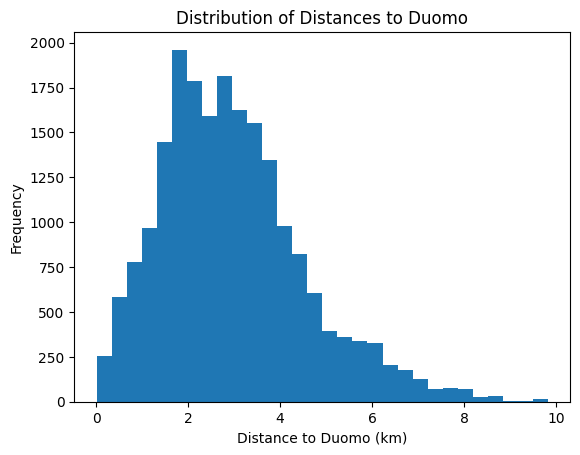


Closest listing to Duomo: 0.019 km
Furthest listing: 9.82 km


In [3]:
duomo_lat = 45.46425
duomo_lan = 9.19179

def haversine_km(lat1, lon1, lat2, lon2): 
    R = 6371 # Earth radius in km's
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distance_to_duomo_km'] = haversine_km(df['latitude'].values, df['longitude'].values, duomo_lat, duomo_lan)

plt.hist(df['distance_to_duomo_km'], bins=30)
plt.xlabel('Distance to Duomo (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Distances to Duomo')
plt.show()

print(f"\nClosest listing to Duomo: {df['distance_to_duomo_km'].min():.3f} km")
print(f"Furthest listing: {df['distance_to_duomo_km'].max():.2f} km")


## Neighborhood encoding(convert strings into a single meaningful number)

In [4]:
neighbourhood_medians = df.groupby('neighbourhood_cleansed')['price_log'].median()
df['neighbourhood_encoded'] = df['neighbourhood_cleansed'].map(neighbourhood_medians)

print("\nTop 10 most expensive neighborhoods (by median price):")
print(
    neighbourhood_medians
    .sort_values(ascending=False)
    .head(10)
    .apply(lambda x: f"${np.expm1(x):.0f}/night median")  # back from log
)
print(neighbourhood_medians.nlargest(10))


Top 10 most expensive neighborhoods (by median price):
neighbourhood_cleansed
DUOMO                     $252/night median
SACCO                     $222/night median
BRERA                     $209/night median
GUASTALLA                 $178/night median
MAGENTA - S. VITTORE      $171/night median
GIARDINI PORTA VENEZIA    $167/night median
GARIBALDI REPUBBLICA      $163/night median
VIGENTINA                 $155/night median
PAGANO                    $148/night median
CANTALUPA                 $148/night median
Name: price_log, dtype: object
neighbourhood_cleansed
DUOMO                     5.533389
SACCO                     5.408367
BRERA                     5.347108
GUASTALLA                 5.187386
MAGENTA - S. VITTORE      5.147494
GIARDINI PORTA VENEZIA    5.123964
GARIBALDI REPUBBLICA      5.102906
VIGENTINA                 5.049856
PAGANO                    5.003946
CANTALUPA                 5.002232
Name: price_log, dtype: float64


## Identifying amenities with a significant impact on pricing

In [5]:
import ast
from scipy import stats

def parse_amenities(amenity_str):
    try:
        return ast.literal_eval(amenity_str)
    except (ValueError, SyntaxError):
        return []
    
df['amenities_list'] = df['amenities'].apply(parse_amenities)
df['amenities_count'] = df['amenities_list'].apply(len)

In [6]:
all_amenities = set()
df['amenities_list'].apply(all_amenities.update)
print(f'Total unique amenities: {len(all_amenities)}')

Total unique amenities: 4080


### Do listings with this amenity have significantly higher prices?

In [7]:
# Test: Mann-Whitney U for each amenity

results = []

for amenity in all_amenities:
    has_amenity = df[df['amenities_list'].apply(lambda lst: amenity in lst)]['price_log']
    no_amenity = df[df['amenities_list'].apply(lambda lst: amenity not in lst)]['price_log']
    
    if len(has_amenity) < 50:
        continue 
    
    # Are the two distributions significantly different?
    stat, p_value = stats.mannwhitneyu(has_amenity, no_amenity, alternative='greater')
    
    # How much more expensive are listings with this amenity?
    median_with = np.expm1(has_amenity.median())
    median_without = np.expm1(no_amenity.median())
    price_premium = median_with / median_without

    results.append({
        'amenity':          amenity,
        'count':            len(has_amenity),
        'pct_listings':     len(has_amenity) / len(df) * 100,
        'median_with':      median_with,
        'median_without':   median_without,
        'price_premium':    price_premium,
        'p_value':          p_value,
    })

results_df = pd.DataFrame(results)


In [8]:
results_df.head()


,amenity,count,pct_listings,median_with,median_without,price_premium,p_value
0,Private backyard – Fully fenced,326,1.602596,116.498936,124.0,0.939508,9.624304e-01
1,Carbon monoxide alarm,8729,42.911218,128.000000,121.0,1.057851,1.551588e-14
2,Clothing storage: walk-in closet,446,2.192508,118.000000,124.0,0.951613,8.897091e-01
3,"Coffee maker: espresso machine, pour-over coffee",162,0.796382,108.498858,124.0,0.874991,9.839473e-01
4,Portable air conditioning,205,1.007767,95.000000,125.0,0.760000,1.000000e+00


### Filter to statistically significant amenities

In [9]:
significant_amenities = ( 
    results_df[results_df['p_value'] < 0.05].sort_values('price_premium', ascending=False) 
    )

print(f"\nAmenities with statistically significant price impact: {len(significant_amenities)}")
print(f"Out of {len(results_df)} amenities tested\n")
print(significant_amenities[['amenity', 'count', 'pct_listings', 
                    'median_with', 'median_without', 
                    'price_premium', 'p_value']]
      .round(2)
      .to_string(index=False))



Amenities with statistically significant price impact: 108
Out of 241 amenities tested

                                                             amenity  count  pct_listings  median_with  median_without  price_premium  p_value
                                 High chair - available upon request    405          1.99       214.00           123.0           1.74     0.00
                                  Noise decibel monitors on property    173          0.85       187.00           124.0           1.51     0.00
                                                             Hot tub    184          0.90       184.50           124.0           1.49     0.00
                                  Baby bath - available upon request    164          0.81       180.00           124.0           1.45     0.00
                                  Paid crib - available upon request   1272          6.25       171.00           121.0           1.41     0.00
                                                     

In [15]:
top_amenities = significant_amenities[significant_amenities['pct_listings'] > 2].head(20) ## Select top 20 amenities with >2% listing presence

print(top_amenities[['amenity', 'count', 'pct_listings']].round(2).to_string(index=False))


                           amenity  count  pct_listings
Paid crib - available upon request   1272          6.25
     Crib - available upon request    981          4.82
                              Safe   1208          5.94
            TV with standard cable    984          4.84
                             Dryer   1315          6.46
                              Crib   1866          9.17
                        High chair    724          3.56
                        Dishwasher  10168         49.99
                        Smart lock   3215         15.80
                  Air conditioning  13037         64.09
          Pack ’n play/Travel crib    824          4.05
                           Toaster   4067         19.99
                            Keypad   1347          6.62
  Paid parking garage off premises   1504          7.39
                           Bathtub   2394         11.77
              Free dryer – In unit   1582          7.78
                             Stove   6591       

### Create binary feature column

In [17]:
def make_feature_name(amenity):
    """Paid crib' → 'has_paid_crib'"""
    clean = amenity.lower()
    clean = re.sub(r'[^a-z0-9\s]', '', clean)
    clean = re.sub(r'\s+', '_', clean.strip())
    return f'has_{clean}'

amenity_feature_map = {
    row['amenity']: make_feature_name(row['amenity'])
    for _, row in top_amenities.iterrows()
}

for amenity, feature_name in amenity_feature_map.items():
    df[feature_name] = df['amenities_list'].apply(
        lambda lst: 1 if amenity in lst else 0
    )

print(f"\n{len(amenity_feature_map)} data-driven amenity features:")
print(list(amenity_feature_map.values()))


20 data-driven amenity features:
['has_paid_crib_available_upon_request', 'has_crib_available_upon_request', 'has_safe', 'has_tv_with_standard_cable', 'has_dryer', 'has_crib', 'has_high_chair', 'has_dishwasher', 'has_smart_lock', 'has_air_conditioning', 'has_pack_n_playtravel_crib', 'has_toaster', 'has_keypad', 'has_paid_parking_garage_off_premises', 'has_bathtub', 'has_free_dryer_in_unit', 'has_stove', 'has_kitchen', 'has_iron', 'has_building_staff']


## Hose Expericence

In [20]:
print(f"For reference_date: '{df['last_scraped'].mode()[0]}'")

For reference_date: '2025-09-24'


In [21]:
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')

reference_date = pd.to_datetime(df['last_scraped'].mode()[0])

df['host_experience_days'] = (reference_date - df['host_since']).dt.days

# Null means we have no info about the host 
median_experience = df['host_experience_days'].median()
df['host_experience_days'] = df['host_experience_days'].fillna(median_experience)

print(df['host_experience_days'].describe().round(1))
print(f"\nMedian host experience: {median_experience/365:.1f} years")
print(f"Newest host: {df['host_experience_days'].min():.0f} days")
print(f"Most experienced host: {df['host_experience_days'].max():.0f} days "
      f"({df['host_experience_days'].max()/365:.1f} years)")

# Quick sanity check: do experienced hosts charge more?
experienced = df[df['host_experience_days'] > median_experience]['price_log']
new_hosts   = df[df['host_experience_days'] <= median_experience]['price_log']
print(f"\nMedian price — experienced hosts: ${np.expm1(experienced.median()):.0f}")
print(f"Median price — newer hosts:       ${np.expm1(new_hosts.median()):.0f}")


count    20342.0
mean      2755.8
std       1477.0
min          4.0
25%       1265.0
50%       3100.5
75%       3995.0
max       5938.0
Name: host_experience_days, dtype: float64

Median host experience: 8.5 years
Newest host: 4 days
Most experienced host: 5938 days (16.3 years)

Median price — experienced hosts: $121
Median price — newer hosts:       $126


## Composite review score

### Correlation Review sub-scores

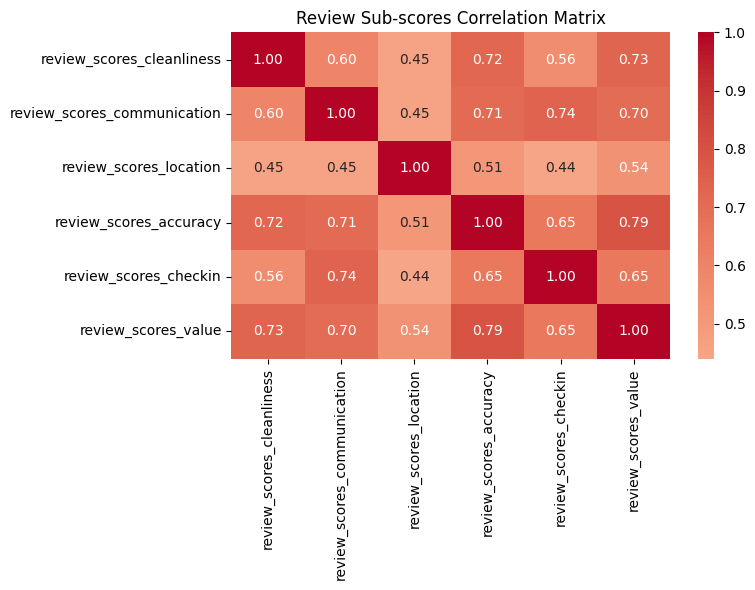

In [37]:
review_subcols = [
    'review_scores_cleanliness',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_accuracy',
    'review_scores_checkin',
    'review_scores_value',
]

corr_matrix = df[review_subcols].corr().round(2)

# print("Correlation matrix of review sub-scores:")
# print(corr_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Review Sub-scores Correlation Matrix')
plt.tight_layout()
plt.show()



Location sub-score is the most distinct, with lowest correlations to others. (Quite intuitive - location is a different aspect than cleanliness or communication)

We will compose them because mean = 0.62(except the location)

In [40]:


review_subcols_no_location = [
    'review_scores_cleanliness',
    'review_scores_communication',
    'review_scores_accuracy',
    'review_scores_checkin',
    'review_scores_value',
]

df['review_scores_rating'] = df['review_scores_rating'].replace(0, np.nan)


df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)

print("Has reviews distribution:")
print(df['has_reviews'].value_counts())
print(f"\nMedian price with reviews:    ${df[df['has_reviews']==1]['price'].median():.0f}")
print(f"Median price without reviews: ${df[df['has_reviews']==0]['price'].median():.0f}")

df['review_composite'] = df[review_subcols_no_location].mean(axis=1)

median_composite = df['review_composite'].median()
df['review_composite'] = df['review_composite'].fillna(median_composite)
df['review_scores_rating'] = df['review_scores_rating'].fillna(
    df['review_scores_rating'].median()
)
df['review_scores_location'] = df['review_scores_location'].fillna(
    df['review_scores_location'].median()
)



print(f"\nNulls in composite: {df['review_composite'].isnull().sum()}")
print(f"Nulls in rating:    {df['review_scores_rating'].isnull().sum()}")
print(f"Nulls in location:  {df['review_scores_location'].isnull().sum()}")
##  Data first, code second:)

Has reviews distribution:
has_reviews
1    17511
0     2831
Name: count, dtype: int64

Median price with reviews:    $123
Median price without reviews: $135

Nulls in composite: 0
Nulls in rating:    0
Nulls in location:  0
